In [50]:
# Ensure python (*.py) files are reloaded correctly while editing them
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [57]:
from huggingface_hub import notebook_login, HfApi
from few_shot.DINOv3Wrapper import DINOv3Wrapper
from mvtechDataset import ensure_mvtech_dataset_is_downloaded, get_categories, load_mvtec_data

api = HfApi()
try:
    who = api.whoami()
    print("logged in as:", who['name'])
except Exception:
    print("not logged in")
    notebook_login()

dataset_path = ensure_mvtech_dataset_is_downloaded(".")
category = "toothbrush"
num_shots = 8

reference_images, test_images, test_labels, test_masks = load_mvtec_data(
    dataset_path, category, num_shots
)

model = DINOv3Wrapper(
    model_name="facebook/dinov3-vitb16-pretrain-lvd1689m",
    smaller_edge_size=1024
)

logged in as: KostyalBalint
Dataset already exists at ./mvtec_anomaly_detection
['transistor', 'wood', 'capsule', 'metal_nut', 'pill', 'zipper', 'tile', 'hazelnut', 'carpet', 'cable', 'leather', 'screw', 'toothbrush', 'bottle', 'grid']
Loaded 8 reference images for toothbrush
Loaded 42 test images (30 anomalous, 12 normal)
Loading facebook/dinov3-vitb16-pretrain-lvd1689m on cpu...
Model loaded! Hidden dim: 768, Register tokens: 4, Patch size: 16
Smaller edge size: 1024


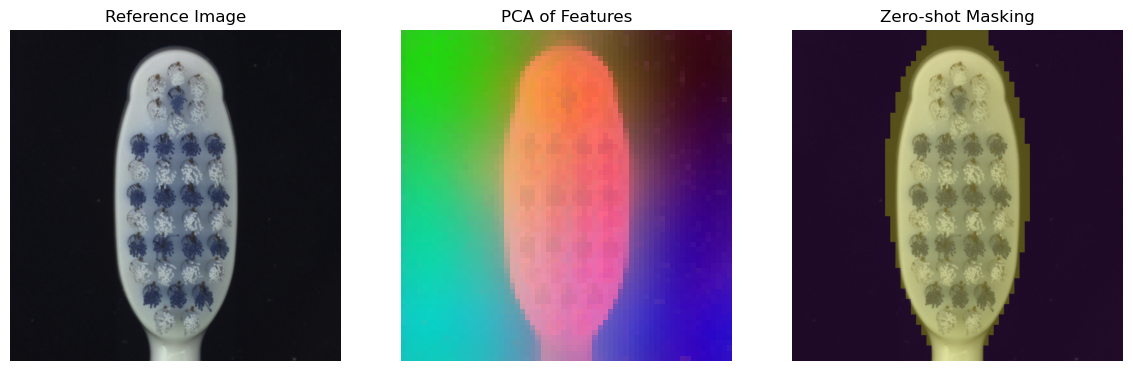

In [86]:
from few_shot.utils import resize_mask_img
import cv2
import matplotlib.pyplot as plt


# Load reference image
object_name = "toothbrush" # change object/image as you like
masking = True
img_name = "001.png"
image_ref = cv2.imread(f"{dataset_path}/{object_name}/train/good/{img_name}")
image_ref = cv2.cvtColor(image_ref, cv2.COLOR_BGR2RGB)

#masking = masking_default[object_name] # set masking = False for textures

# Compute features and mask
image_tensor1, grid_size1 = model.prepare_image(image_ref)
features_ref = model.extract_features(image_tensor1)
mask_ref = model.compute_background_mask(features_ref, grid_size1, masking_type=masking, n_components=1)
vis_image_ref = model.get_embedding_visualization(features_ref, grid_size1)

# Visualization: 1 = clean reference image, 2 = PCA-dimensions (top 3) of features, 3 = zero-shot masking (PCA[0] > 10)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4))
ax1.imshow(image_ref)
ax2.imshow(vis_image_ref)
resized_mask = resize_mask_img(mask_ref, image_ref.shape, grid_size1)
ax3.imshow(image_ref)
# prepare_mask
ax3.imshow(resize_mask_img(mask_ref, image_ref.shape, grid_size1), alpha=0.3)
# ax3.imshow(model.prepare_mask(mask_ref, image_ref.shape, grid_size1), alpha=0.3)
fig.tight_layout()
ax1.axis('off')
ax1.set_title("Reference Image")
ax2.axis('off')
ax2.set_title("PCA of Features")
ax3.axis('off')
ax3.set_title("Zero-shot Masking")
plt.show()

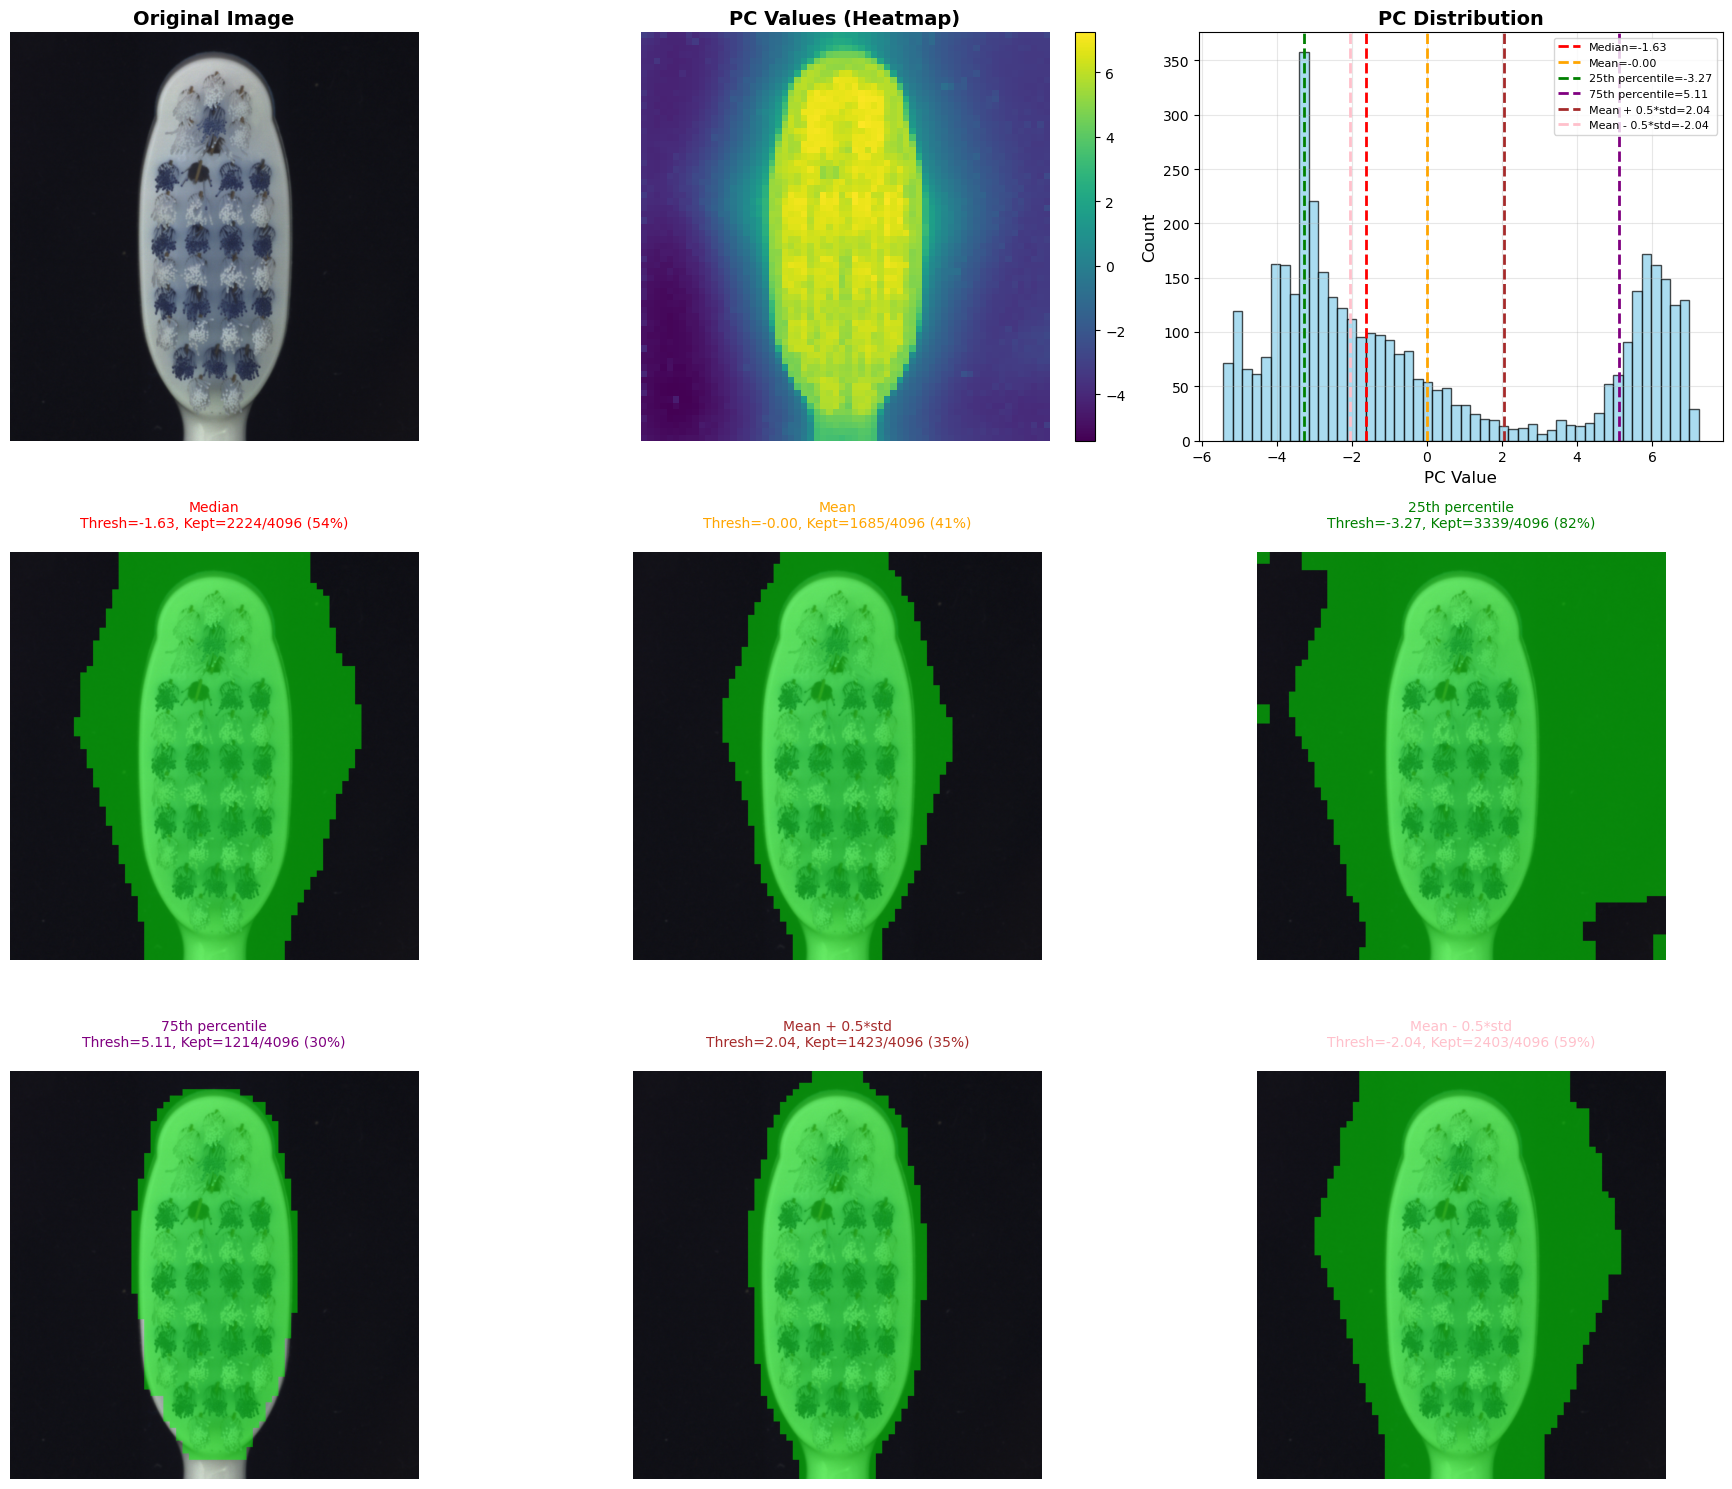


Threshold Comparison Summary:
Median              : thresh=  -1.63, kept=2048/4096 ( 50.0%), flip=False
Mean                : thresh=  -0.00, kept=1516/4096 ( 37.0%), flip=False
25th percentile     : thresh=  -3.27, kept=3072/4096 ( 75.0%), flip=False
75th percentile     : thresh=   5.11, kept=1024/4096 ( 25.0%), flip=False
Mean + 0.5*std      : thresh=   2.04, kept=1250/4096 ( 30.5%), flip=False
Mean - 0.5*std      : thresh=  -2.04, kept=2219/4096 ( 54.2%), flip=False


In [59]:
import cv2
import numpy as np
from sklearn.decomposition import PCA
from matplotlib import pyplot as plt

# Compare different thresholding strategies
demo_idx = 1  # Pick an image to analyze
demo_img = test_images[demo_idx]

# Extract features
img_tensor, grid_sz = model.prepare_image(demo_img)
feats = model.extract_features(img_tensor)

# Compute PCA
pca_explore = PCA(n_components=1, svd_solver='randomized', random_state=42)
pc_vals = pca_explore.fit_transform(feats.astype(np.float32)).flatten()

# Try different threshold strategies
thresholds = {
    'Median': np.median(pc_vals),
    'Mean': np.mean(pc_vals),
    '25th percentile': np.percentile(pc_vals, 25),
    '75th percentile': np.percentile(pc_vals, 75),
    'Mean + 0.5*std': np.mean(pc_vals) + 0.5 * np.std(pc_vals),
    'Mean - 0.5*std': np.mean(pc_vals) - 0.5 * np.std(pc_vals),
}

# Visualize
fig, axes = plt.subplots(3, 3, figsize=(18, 15))

# Original image
axes[0, 0].imshow(demo_img)
axes[0, 0].set_title('Original Image', fontsize=14, fontweight='bold')
axes[0, 0].axis('off')

# PC values with histogram
pc_2d = pc_vals.reshape(grid_sz)
im = axes[0, 1].imshow(pc_2d, cmap='viridis')
axes[0, 1].set_title('PC Values (Heatmap)', fontsize=14, fontweight='bold')
axes[0, 1].axis('off')
plt.colorbar(im, ax=axes[0, 1], fraction=0.046)

# Histogram with all thresholds marked
axes[0, 2].hist(pc_vals, bins=50, alpha=0.7, edgecolor='black', color='skyblue')
colors = ['red', 'orange', 'green', 'purple', 'brown', 'pink']
for i, (name, thresh) in enumerate(thresholds.items()):
    axes[0, 2].axvline(thresh, color=colors[i], linestyle='--', linewidth=2, label=f'{name}={thresh:.2f}')
axes[0, 2].set_xlabel('PC Value', fontsize=12)
axes[0, 2].set_ylabel('Count', fontsize=12)
axes[0, 2].set_title('PC Distribution', fontsize=14, fontweight='bold')
axes[0, 2].legend(fontsize=8, loc='upper right')
axes[0, 2].grid(alpha=0.3)

# Apply each threshold and visualize
for idx, (name, thresh) in enumerate(thresholds.items()):
    row = 1 + idx // 3
    col = idx % 3

    # Apply threshold
    mask = pc_vals > thresh

    # Check if should flip (center region check)
    mask_2d = mask.reshape(grid_sz)
    h, w = grid_sz
    center_region = mask_2d[int(h * 0.2):int(h * 0.8), int(w * 0.2):int(w * 0.8)]

    should_flip = center_region.size > 0 and center_region.sum() <= center_region.size * 0.35
    if should_flip:
        mask = ~mask
        mask_2d = mask.reshape(grid_sz)

    # Apply morphology
    mask_morph = mask_2d.astype(np.uint8)
    kernel = np.ones((3, 3), np.uint8)
    mask_morph = cv2.dilate(mask_morph, kernel, iterations=1)
    mask_morph = cv2.morphologyEx(mask_morph, cv2.MORPH_CLOSE, kernel, iterations=1)

    # Overlay on image
    mask_overlay = cv2.resize(mask_morph * 255,
                              (demo_img.shape[1], demo_img.shape[0]),
                              interpolation=cv2.INTER_NEAREST)
    overlay = demo_img.copy()
    overlay[mask_overlay > 0] = overlay[mask_overlay > 0] * 0.5 + np.array([0, 255, 0]) * 0.5

    axes[row, col].imshow(overlay.astype(np.uint8))
    axes[row, col].set_title(
        f'{name}\nThresh={thresh:.2f}, Kept={mask_morph.sum()}/{grid_sz[0]*grid_sz[1]} ({mask_morph.sum()/(grid_sz[0]*grid_sz[1])*100:.0f}%)\n{"(Flipped)" if should_flip else ""}',
        fontsize=10, color=colors[idx]
    )
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

print(f"\n{'='*70}")
print("Threshold Comparison Summary:")
print(f"{'='*70}")
for name, thresh in thresholds.items():
    mask = pc_vals > thresh
    # Check flip
    mask_2d = mask.reshape(grid_sz)
    center_region = mask_2d[int(h * 0.2):int(h * 0.8), int(w * 0.2):int(w * 0.8)]
    should_flip = center_region.size > 0 and center_region.sum() <= center_region.size * 0.35
    if should_flip:
        mask = ~mask
    print(f"{name:20s}: thresh={thresh:7.2f}, kept={mask.sum():3d}/{len(mask)} ({mask.sum()/len(mask)*100:5.1f}%), flip={should_flip}")
print(f"{'='*70}")

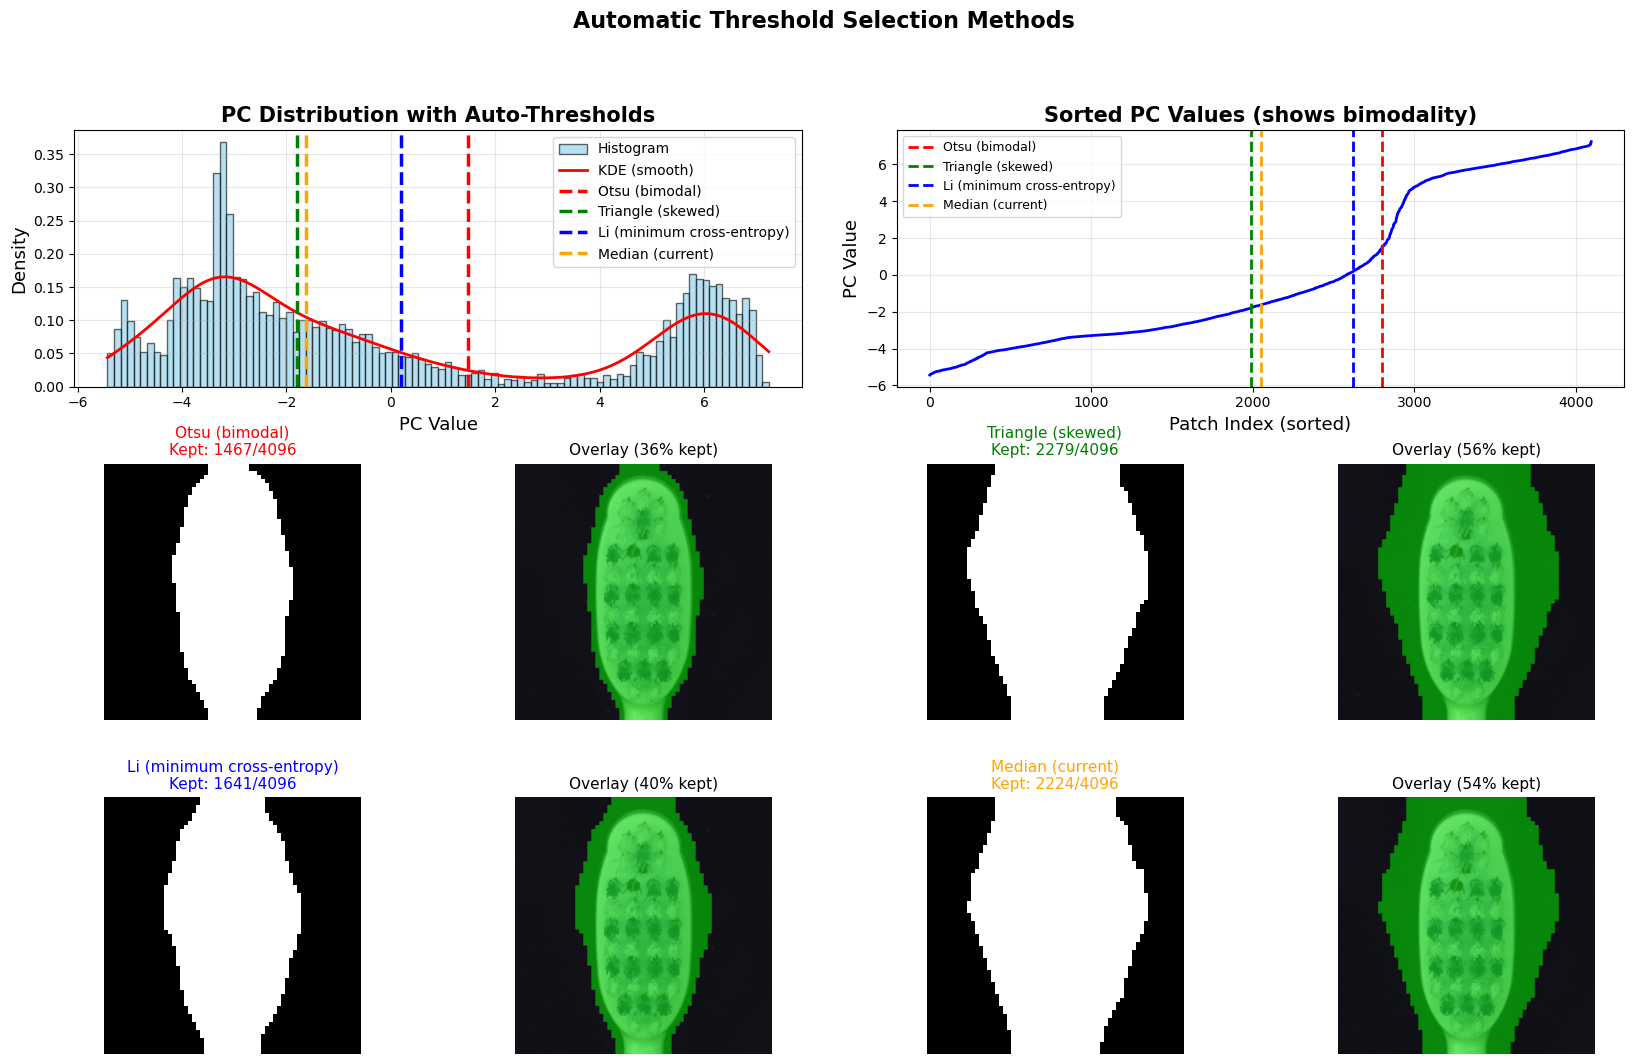

In [60]:
from skimage.filters import threshold_otsu, threshold_triangle, threshold_li
from scipy.stats import gaussian_kde

# Use same image as before
demo_img = test_images[demo_idx]
img_tensor, grid_sz = model.prepare_image(demo_img)
feats = model.extract_features(img_tensor)

# Compute PCA
pca_auto = PCA(n_components=1, svd_solver='randomized', random_state=42)
pc_vals = pca_auto.fit_transform(feats.astype(np.float32)).flatten()

# Normalize PC values to 0-255 for Otsu (it expects uint8)
pc_normalized = ((pc_vals - pc_vals.min()) / (pc_vals.max() - pc_vals.min()) * 255).astype(np.uint8)

# Try automatic thresholding methods
try:
    otsu_thresh_norm = threshold_otsu(pc_normalized)
    otsu_thresh = pc_vals.min() + (otsu_thresh_norm / 255) * (pc_vals.max() - pc_vals.min())
except:
    otsu_thresh = np.median(pc_vals)

try:
    triangle_thresh_norm = threshold_triangle(pc_normalized)
    triangle_thresh = pc_vals.min() + (triangle_thresh_norm / 255) * (pc_vals.max() - pc_vals.min())
except:
    triangle_thresh = np.median(pc_vals)

try:
    li_thresh_norm = threshold_li(pc_normalized)
    li_thresh = pc_vals.min() + (li_thresh_norm / 255) * (pc_vals.max() - pc_vals.min())
except:
    li_thresh = np.median(pc_vals)

# Compare methods
auto_thresholds = {
    'Otsu (bimodal)': otsu_thresh,
    'Triangle (skewed)': triangle_thresh,
    'Li (minimum cross-entropy)': li_thresh,
    'Median (current)': np.median(pc_vals),
}

# Visualize with KDE
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 4, hspace=0.3, wspace=0.3)

# Top row: Distribution analysis
ax1 = fig.add_subplot(gs[0, :2])
ax1.hist(pc_vals, bins=100, alpha=0.6, density=True, color='skyblue', edgecolor='black', label='Histogram')

# Add KDE for smooth distribution
kde = gaussian_kde(pc_vals)
x_range = np.linspace(pc_vals.min(), pc_vals.max(), 1000)
ax1.plot(x_range, kde(x_range), 'r-', linewidth=2, label='KDE (smooth)')

# Mark thresholds
colors_auto = ['red', 'green', 'blue', 'orange']
for i, (name, thresh) in enumerate(auto_thresholds.items()):
    ax1.axvline(thresh, color=colors_auto[i], linestyle='--', linewidth=2.5, label=f'{name}')

ax1.set_xlabel('PC Value', fontsize=13)
ax1.set_ylabel('Density', fontsize=13)
ax1.set_title('PC Distribution with Auto-Thresholds', fontsize=15, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)

# Bimodality check
ax2 = fig.add_subplot(gs[0, 2:])
sorted_vals = np.sort(pc_vals)
ax2.plot(sorted_vals, 'b-', linewidth=2)
for i, (name, thresh) in enumerate(auto_thresholds.items()):
    thresh_idx = np.searchsorted(sorted_vals, thresh)
    ax2.axvline(thresh_idx, color=colors_auto[i], linestyle='--', linewidth=2, label=name)
ax2.set_xlabel('Patch Index (sorted)', fontsize=13)
ax2.set_ylabel('PC Value', fontsize=13)
ax2.set_title('Sorted PC Values (shows bimodality)', fontsize=15, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

# Bottom rows: Compare masks
for idx, (name, thresh) in enumerate(auto_thresholds.items()):
    row = 1 + idx // 2
    col = (idx % 2) * 2

    # Apply threshold
    mask = pc_vals > thresh

    # Flip check
    mask_2d = mask.reshape(grid_sz)
    h, w = grid_sz
    center_region = mask_2d[int(h * 0.2):int(h * 0.8), int(w * 0.2):int(w * 0.8)]
    should_flip = center_region.size > 0 and center_region.sum() <= center_region.size * 0.35
    if should_flip:
        mask = ~mask
        mask_2d = mask.reshape(grid_sz)

    # Morphology
    mask_morph = mask_2d.astype(np.uint8)
    kernel = np.ones((3, 3), np.uint8)
    mask_morph = cv2.dilate(mask_morph, kernel, iterations=1)
    mask_morph = cv2.morphologyEx(mask_morph, cv2.MORPH_CLOSE, kernel, iterations=1)

    # Show binary mask
    ax_mask = fig.add_subplot(gs[row, col])
    ax_mask.imshow(mask_morph, cmap='gray')
    ax_mask.set_title(f'{name}\nKept: {mask_morph.sum()}/{grid_sz[0]*grid_sz[1]}', fontsize=11, color=colors_auto[idx])
    ax_mask.axis('off')

    # Show overlay
    ax_overlay = fig.add_subplot(gs[row, col+1])
    mask_overlay = cv2.resize(mask_morph * 255,
                              (demo_img.shape[1], demo_img.shape[0]),
                              interpolation=cv2.INTER_NEAREST)
    overlay = demo_img.copy()
    overlay[mask_overlay > 0] = overlay[mask_overlay > 0] * 0.5 + np.array([0, 255, 0]) * 0.5
    ax_overlay.imshow(overlay.astype(np.uint8))
    ax_overlay.set_title(f'Overlay ({mask_morph.sum()/(grid_sz[0]*grid_sz[1])*100:.0f}% kept)', fontsize=11)
    ax_overlay.axis('off')

plt.suptitle('Automatic Threshold Selection Methods', fontsize=16, fontweight='bold', y=0.98)
plt.show()

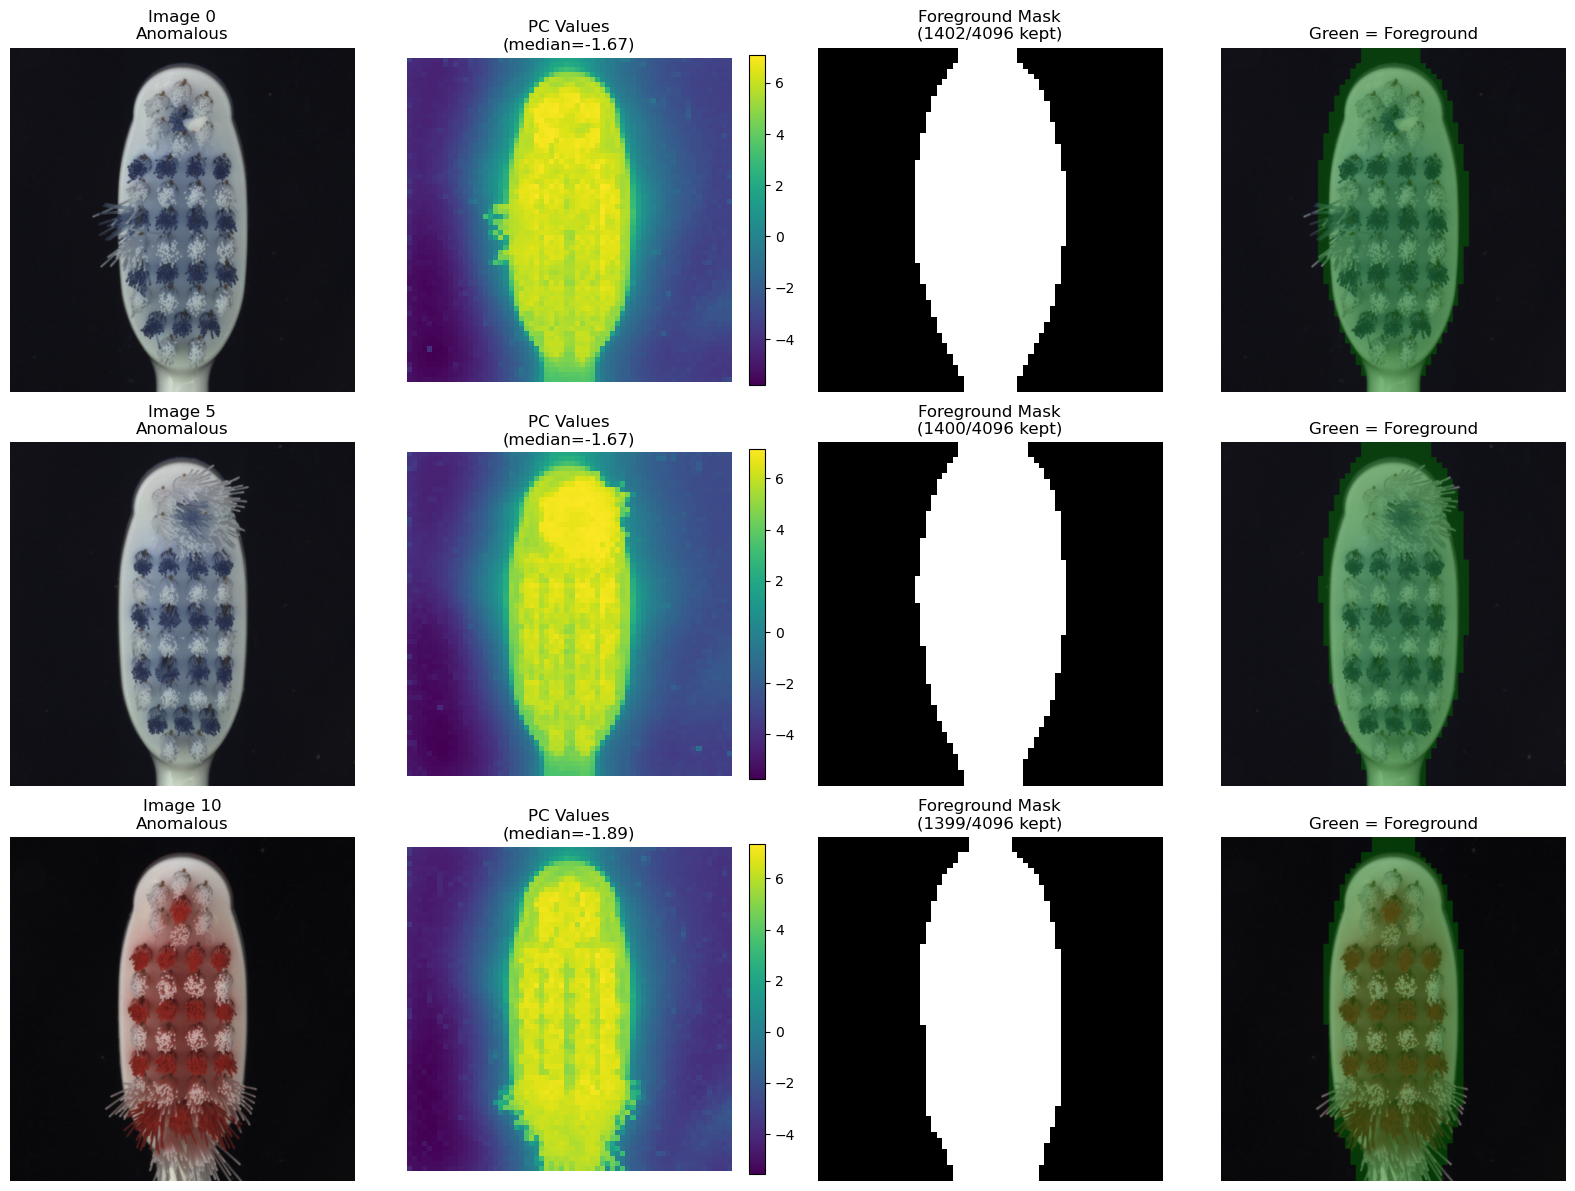

In [61]:
# Compare multiple test images to see masking behavior
fig, axes = plt.subplots(3, 4, figsize=(16, 12))

# Select 3 different test images
test_indices = [0, 5, 10]  # Normal, anomalous samples

for row, idx in enumerate(test_indices):
    img = test_images[idx]
    label = test_labels[idx]

    # Extract features and compute mask
    img_tensor, grid_sz = model.prepare_image(img)
    feats = model.extract_features(img_tensor)

    # Compute PCA
    pca_temp = PCA(n_components=1, svd_solver='randomized', random_state=42)
    pc = pca_temp.fit_transform(feats.astype(np.float32)).flatten()

    # Get mask
    mask = model.compute_background_mask(feats, grid_sz, masking_type=True)

    # Column 1: Original image
    axes[row, 0].imshow(img)
    axes[row, 0].set_title(f'Image {idx}\n{"Anomalous" if label == 1 else "Normal"}', fontsize=12)
    axes[row, 0].axis('off')

    # Column 2: PC heatmap
    pc_2d = pc.reshape(grid_sz)
    im = axes[row, 1].imshow(pc_2d, cmap='viridis')
    axes[row, 1].set_title(f'PC Values\n(median={np.median(pc):.2f})', fontsize=12)
    axes[row, 1].axis('off')
    plt.colorbar(im, ax=axes[row, 1], fraction=0.046)

    # Column 3: Binary mask
    mask_2d = mask.reshape(grid_sz)
    axes[row, 2].imshow(mask_2d, cmap='gray')
    axes[row, 2].set_title(f'Foreground Mask\n({mask.sum()}/{len(mask)} kept)', fontsize=12)
    axes[row, 2].axis('off')

    # Column 4: Overlay on image
    mask_resized = cv2.resize(mask_2d.astype(np.uint8) * 255,
                              (img.shape[1], img.shape[0]),
                              interpolation=cv2.INTER_NEAREST)
    overlay_img = img.copy()
    overlay_img[mask_resized > 0] = overlay_img[mask_resized > 0] * 0.6 + np.array([0, 128, 0]) * 0.4
    axes[row, 3].imshow(overlay_img.astype(np.uint8))
    axes[row, 3].set_title('Green = Foreground', fontsize=12)
    axes[row, 3].axis('off')

plt.tight_layout()
plt.show()